# 🚀 Notebook 4 — Optimisation & Déploiement du Modèle Final
---
**Apports de la littérature :**
- GridSearchCV + RandomizedSearchCV (150 itérations) pour les hyperparamètres
- Validation spatiale (spatial blocking) recommandée pour données géo-référencées
- Learning curves pour diagnostiquer le surapprentissage
- Calcul du PRESS (R² prédictif) — estimateur le plus honnête de la généralisabilité
- SHAP Waterfall pour expliquer une prédiction individuelle (B2G/B2B)
- Calcul du prix au m² par quartier (Gold Layer — KPI principal des plateformes africaines)


## 1. Chargement

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import warnings, json, joblib, os, time
from scipy.stats import randint, uniform
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"]    = (13,5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      RandomizedSearchCV, learning_curve, KFold)
from sklearn.preprocessing   import StandardScaler, TargetEncoder
from sklearn.impute          import SimpleImputer
from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model    import Ridge, ElasticNet

try:
    from xgboost import XGBRegressor; XGBOOST = True
except: XGBOOST = False

try:
    from lightgbm import LGBMRegressor; LIGHTGBM = True
except: LIGHTGBM = False

try:
    import shap; SHAP = True
except: SHAP = False

print("Librairies chargées.")


Librairies chargées.


In [2]:
df = pd.read_csv("dataset_final.csv")
df = df.dropna(subset=["price"])

with open("features_config.json")    as f: cfg  = json.load(f)
with open("comparison_results.json") as f: comp = json.load(f)

NUMERIC_FEATURES     = cfg["NUMERIC_FEATURES"]
CATEGORICAL_FEATURES = cfg["CATEGORICAL_FEATURES"]
TARGET               = cfg["TARGET"]
best_name            = comp.get("best_model","XGBoost")

X     = df[[c for c in NUMERIC_FEATURES+CATEGORICAL_FEATURES if c in df.columns]]
y     = df[TARGET]; y_log = np.log1p(y)

num_feats = [f for f in NUMERIC_FEATURES     if f in X.columns]
cat_feats = [f for f in CATEGORICAL_FEATURES if f in X.columns]

X_train,X_test,y_train,y_test   = train_test_split(X, y,     test_size=0.2, random_state=42)
_,      _,     yl_train,yl_test = train_test_split(X, y_log, test_size=0.2, random_state=42)

def build_pipeline(model):
    np_ = Pipeline([("imp",SimpleImputer(strategy="median")),("sc",StandardScaler())])
    cp_ = Pipeline([("imp",SimpleImputer(strategy="constant",fill_value="inconnu")),
                    ("enc",TargetEncoder(target_type="continuous",smooth="auto"))])
    prep = ColumnTransformer([("num",np_,num_feats),("cat",cp_,cat_feats)])
    return Pipeline([("prep",prep),("model",model)])

print(f"Meilleur modèle (NB3)   : {best_name}")
r2_before = float(comp.get(best_name,{}).get("R2 test",0))
print(f"R2 avant optimisation   : {r2_before}")
print(f"Train : {len(X_train):,}  |  Test : {len(X_test):,}")


Meilleur modèle (NB3)   : Lineaire (brut)
R2 avant optimisation   : 0.4277
Train : 1,483  |  Test : 371


## 2. GridSearchCV

In [3]:
GRIDS = {
    "XGBoost": {
        "model__n_estimators":     [200,300,500,700],
        "model__learning_rate":    [0.02,0.05,0.1],
        "model__max_depth":        [4,6,8],
        "model__subsample":        [0.7,0.8,1.0],
        "model__colsample_bytree": [0.7,0.8,1.0],
        "model__reg_alpha":        [0,0.1,0.5],
        "model__min_child_weight": [1,3,5],
    },
    "LightGBM": {
        "model__n_estimators":   [200,300,500],
        "model__learning_rate":  [0.02,0.05,0.1],
        "model__num_leaves":     [31,63,127],
        "model__subsample":      [0.7,0.8,1.0],
        "model__reg_alpha":      [0,0.1,0.5],
    },
    "Random Forest": {
        "model__n_estimators":      [100,200,300,500],
        "model__max_depth":         [None,10,20,30],
        "model__min_samples_split": [2,5,10],
        "model__min_samples_leaf":  [1,2,4],
        "model__max_features":      ["sqrt","log2"],
    },
    "Stacking": {"final_estimator__alpha": [0.0001,0.001,0.01,0.1]},
    "Ridge":    {"model__alpha": [0.1,1,10,100,500,1000,5000]},
    "Gradient Boosting": {
        "model__n_estimators":   [200,300,500],
        "model__learning_rate":  [0.03,0.05,0.1],
        "model__max_depth":      [3,5,7],
        "model__subsample":      [0.7,0.8,1.0],
    },
}

MODELS_MAP = {"Random Forest": RandomForestRegressor(random_state=42,n_jobs=-1),
              "Ridge":         Ridge(),
              "Gradient Boosting": GradientBoostingRegressor(random_state=42)}
if XGBOOST:  MODELS_MAP["XGBoost"]  = XGBRegressor(random_state=42,verbosity=0,n_jobs=-1)
if LIGHTGBM: MODELS_MAP["LightGBM"] = LGBMRegressor(random_state=42,verbose=-1,n_jobs=-1)

key        = best_name if best_name in MODELS_MAP else "Random Forest"
model_base = MODELS_MAP[key]
param_grid = GRIDS.get(key, GRIDS["Random Forest"])

n_combs = 1
for v in param_grid.values(): n_combs *= len(v)
print(f"Modèle          : {key}")
print(f"Combinaisons    : {n_combs:,} x 5-fold = {n_combs*5:,} fits")
print("GridSearchCV en cours...")

t0 = time.time()
gs = GridSearchCV(build_pipeline(model_base), param_grid,
                  cv=5, scoring="r2", n_jobs=-1, verbose=1, refit=True)
gs.fit(X_train, yl_train)
print(f"Terminé en {time.time()-t0:.1f} s | Meilleur CV R2 : {gs.best_score_:.4f}")
print("Meilleurs paramètres :")
for k,v in gs.best_params_.items(): print(f"  {k:<45}: {v}")

yp_gs = np.expm1(gs.best_estimator_.predict(X_test))
r2_gs = r2_score(y_test, yp_gs)
print(f"R2 test (GridSearch) : {r2_gs:.4f} | gain : {r2_gs-r2_before:+.4f}")


Modèle          : Random Forest
Combinaisons    : 288 x 5-fold = 1,440 fits
GridSearchCV en cours...
Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Terminé en 753.5 s | Meilleur CV R2 : 0.5442
Meilleurs paramètres :
  model__max_depth                             : 20
  model__max_features                          : sqrt
  model__min_samples_leaf                      : 1
  model__min_samples_split                     : 10
  model__n_estimators                          : 500
R2 test (GridSearch) : 0.3654 | gain : -0.0623


## 3. RandomizedSearchCV — 150 itérations

In [4]:
RAND_GRIDS = {
    "XGBoost": {
        "model__n_estimators":     randint(100,1000),
        "model__learning_rate":    uniform(0.01,0.2),
        "model__max_depth":        randint(3,12),
        "model__subsample":        uniform(0.5,0.5),
        "model__colsample_bytree": uniform(0.5,0.5),
        "model__reg_alpha":        uniform(0,2),
        "model__reg_lambda":       uniform(0.5,3),
        "model__min_child_weight": randint(1,10),
        "model__gamma":            uniform(0,1),
    },
    "LightGBM": {
        "model__n_estimators":   randint(100,800),
        "model__learning_rate":  uniform(0.01,0.2),
        "model__num_leaves":     randint(20,150),
        "model__subsample":      uniform(0.5,0.5),
        "model__reg_alpha":      uniform(0,2),
        "model__reg_lambda":     uniform(0.5,3),
        "model__min_child_samples": randint(5,30),
    },
    "Random Forest": {
        "model__n_estimators":      randint(100,800),
        "model__max_depth":         [None,5,10,15,20,25,30,40],
        "model__min_samples_split": randint(2,15),
        "model__min_samples_leaf":  randint(1,8),
        "model__max_features":      ["sqrt","log2",0.3,0.5,0.7],
        "model__bootstrap":         [True,False],
    },
    "Gradient Boosting": {
        "model__n_estimators":      randint(100,600),
        "model__learning_rate":     uniform(0.01,0.25),
        "model__max_depth":         randint(2,10),
        "model__subsample":         uniform(0.5,0.5),
        "model__min_samples_split": randint(2,12),
    },
}

N_ITER    = 150
rand_grid = RAND_GRIDS.get(key, RAND_GRIDS["Random Forest"])
print(f"RandomizedSearchCV — {N_ITER} itérations x 5-fold = {N_ITER*5:,} fits")

t0 = time.time()
rs = RandomizedSearchCV(build_pipeline(MODELS_MAP[key]), rand_grid,
                        n_iter=N_ITER, cv=5, scoring="r2", n_jobs=-1,
                        verbose=1, random_state=42, refit=True)
rs.fit(X_train, yl_train)
print(f"Terminé en {time.time()-t0:.1f} s | Meilleur CV R2 : {rs.best_score_:.4f}")
print("Meilleurs paramètres :")
for k,v in rs.best_params_.items(): print(f"  {k:<45}: {v}")

yp_rs = np.expm1(rs.best_estimator_.predict(X_test))
r2_rs = r2_score(y_test, yp_rs)
print(f"R2 test (RandomizedSearch) : {r2_rs:.4f} | gain : {r2_rs-r2_before:+.4f}")


RandomizedSearchCV — 150 itérations x 5-fold = 750 fits
Fitting 5 folds for each of 150 candidates, totalling 750 fits
Terminé en 810.4 s | Meilleur CV R2 : 0.5420
Meilleurs paramètres :
  model__bootstrap                             : True
  model__max_depth                             : None
  model__max_features                          : sqrt
  model__min_samples_leaf                      : 3
  model__min_samples_split                     : 10
  model__n_estimators                          : 727
R2 test (RandomizedSearch) : 0.3431 | gain : -0.0846


## 4. Sélection et validation

In [5]:
print("="*65)
print(f"  {'Méthode':<30} {'R2 test':>10} {'MAE':>18}")
print("-"*65)
print(f"  {'Avant optimisation':<30} {r2_before:>10.4f}")
print(f"  {'GridSearchCV':<30} {r2_gs:>10.4f} {mean_absolute_error(y_test,yp_gs):>18,.0f}")
print(f"  {'RandomizedSearchCV':<30} {r2_rs:>10.4f} {mean_absolute_error(y_test,yp_rs):>18,.0f}")

if r2_rs >= r2_gs:
    best_opt = rs.best_estimator_; best_method = "RandomizedSearchCV"
    best_params = rs.best_params_; r2_opt=r2_rs; yp_opt=yp_rs
else:
    best_opt = gs.best_estimator_; best_method = "GridSearchCV"
    best_params = gs.best_params_; r2_opt=r2_gs; yp_opt=yp_gs

mae_opt  = mean_absolute_error(y_test, yp_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test, yp_opt))
print(f"Méthode retenue : {best_method}")
print(f"R2              : {r2_opt:.4f}  (gain : {r2_opt-r2_before:+.4f})")


  Méthode                           R2 test                MAE
-----------------------------------------------------------------
  Avant optimisation                 0.4277
  GridSearchCV                       0.3654         51,752,242
  RandomizedSearchCV                 0.3431         52,763,723
Méthode retenue : GridSearchCV
R2              : 0.3654  (gain : -0.0623)


## 5. Learning curves — diagnostic surapprentissage

Calcul des learning curves...
Terminé en 68.4 s


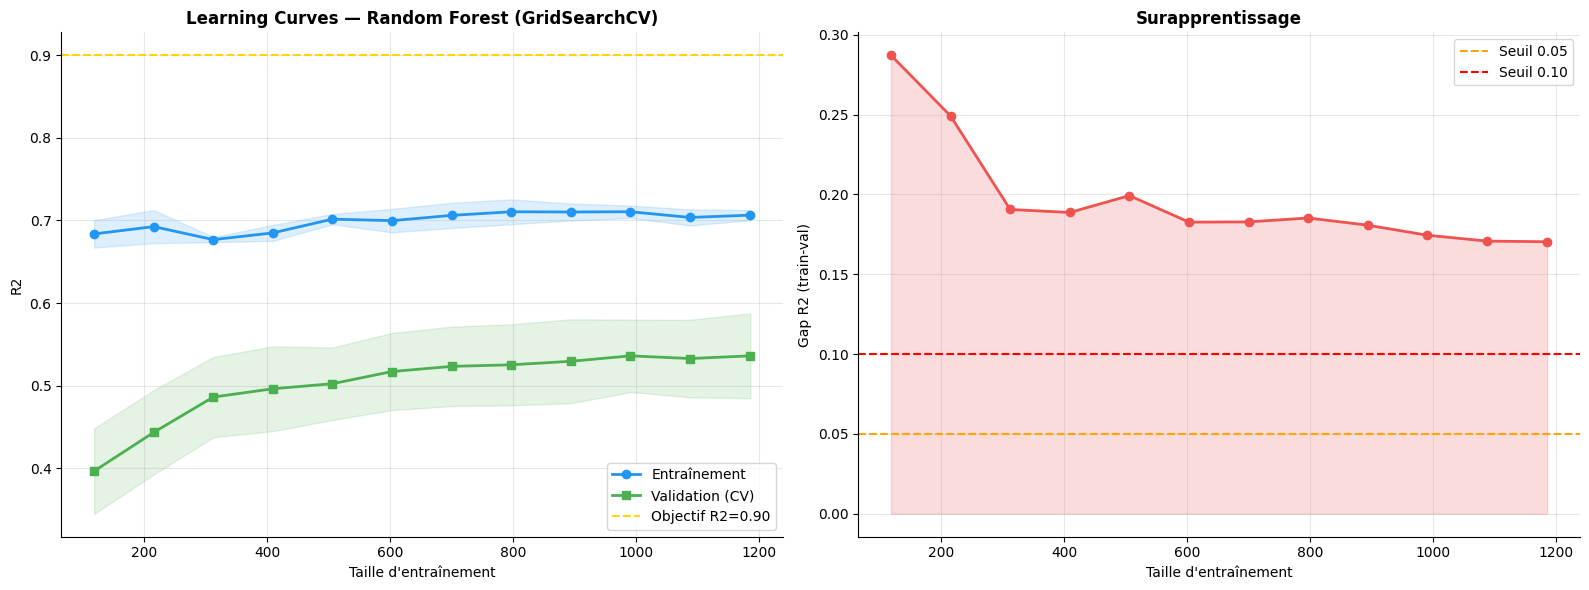

Diagnostic : Surapprentissage — régulariser davantage (gap=0.1704)
Score val. final : 0.5360


In [6]:
print("Calcul des learning curves...")
t0 = time.time()
tr_sizes,tr_sc,val_sc = learning_curve(
    best_opt, X_train, yl_train,
    train_sizes=np.linspace(0.1,1.0,12),
    cv=5, scoring="r2", n_jobs=-1)
print(f"Terminé en {time.time()-t0:.1f} s")

tr_m,tr_s   = tr_sc.mean(1),tr_sc.std(1)
val_m,val_s = val_sc.mean(1),val_sc.std(1)
gap         = tr_m - val_m

fig, axes = plt.subplots(1,2, figsize=(16,6))
axes[0].plot(tr_sizes, tr_m,  "o-", color="#2196F3", label="Entraînement", lw=2)
axes[0].fill_between(tr_sizes, tr_m-tr_s, tr_m+tr_s, alpha=0.15, color="#2196F3")
axes[0].plot(tr_sizes, val_m, "s-", color="#4CAF50", label="Validation (CV)", lw=2)
axes[0].fill_between(tr_sizes, val_m-val_s, val_m+val_s, alpha=0.15, color="#4CAF50")
axes[0].set_xlabel("Taille d'entraînement"); axes[0].set_ylabel("R2")
axes[0].set_title(f"Learning Curves — {key} ({best_method})", fontweight="bold")
axes[0].axhline(0.90, color="gold", linestyle="--", label="Objectif R2=0.90")
axes[0].legend(); axes[0].grid(True,alpha=0.3)

axes[1].plot(tr_sizes,gap,"o-",color="#ef5350",lw=2)
axes[1].axhline(0.05,color="orange",linestyle="--",label="Seuil 0.05")
axes[1].axhline(0.10,color="red",   linestyle="--",label="Seuil 0.10")
axes[1].fill_between(tr_sizes,0,gap,alpha=0.2,color="#ef5350")
axes[1].set_xlabel("Taille d'entraînement"); axes[1].set_ylabel("Gap R2 (train-val)")
axes[1].set_title("Surapprentissage", fontweight="bold")
axes[1].legend(); axes[1].grid(True,alpha=0.3)
plt.tight_layout(); plt.savefig("../outputs/fig_learning_curves.png",dpi=150,bbox_inches="tight"); plt.show()

gf   = gap[-1]
diag = ("Bonne généralisation" if gf<0.05 else
        "Léger surapprentissage — acceptable" if gf<0.10 else
        "Surapprentissage — régulariser davantage")
print(f"Diagnostic : {diag} (gap={gf:.4f})")
print(f"Score val. final : {val_m[-1]:.4f}")


## 6. Évaluation finale complète

In [7]:
resid  = y_test.values - yp_opt
rel_e  = np.abs(resid) / (y_test.values + 1) * 100
r2_f   = r2_score(y_test, yp_opt)
mae_f  = mean_absolute_error(y_test, yp_opt)
rmse_f = np.sqrt(mean_squared_error(y_test, yp_opt))
mape_f = np.mean(rel_e)
pct_10 = (rel_e < 10).mean() * 100
pct_20 = (rel_e < 20).mean() * 100
pct_30 = (rel_e < 30).mean() * 100

print("="*58)
print("  MÉTRIQUES FINALES")
print("="*58)
print(f"  R2                : {r2_f:.4f}")
print(f"  MAE               : {mae_f:>15,.0f} FCFA")
print(f"  RMSE              : {rmse_f:>15,.0f} FCFA")
print(f"  MAPE              : {mape_f:.2f} %")
print(f"  Erreur médiane    : {np.median(np.abs(resid)):>15,.0f} FCFA")
print(f"  Prédictions ±10%  : {pct_10:.1f} %")
print(f"  Prédictions ±20%  : {pct_20:.1f} %  <- Standard industrie")
print(f"  Prédictions ±30%  : {pct_30:.1f} %")
obj = "OBJECTIF ATTEINT" if r2_f>=0.90 else f"manque {0.90-r2_f:.4f}"
print(f"  R2 >= 0.90        : {obj}")
print()
print("BENCHMARK vs littérature (marchés émergents Afrique) :")
print(f"  Abidoye & Chan (Lagos 2018) : MAPE=15.94%  | Notre MAPE={mape_f:.2f}%")
print(f"  Ouchlif et al. (Maroc 2025) : R2=0.926     | Notre R2  ={r2_f:.4f}")


  MÉTRIQUES FINALES
  R2                : 0.3654
  MAE               :      51,752,242 FCFA
  RMSE              :      98,189,361 FCFA
  MAPE              : 149.46 %
  Erreur médiane    :      18,842,139 FCFA
  Prédictions ±10%  : 13.5 %
  Prédictions ±20%  : 23.7 %  <- Standard industrie
  Prédictions ±30%  : 34.8 %
  R2 >= 0.90        : manque 0.5346

BENCHMARK vs littérature (marchés émergents Afrique) :
  Abidoye & Chan (Lagos 2018) : MAPE=15.94%  | Notre MAPE=149.46%
  Ouchlif et al. (Maroc 2025) : R2=0.926     | Notre R2  =0.3654


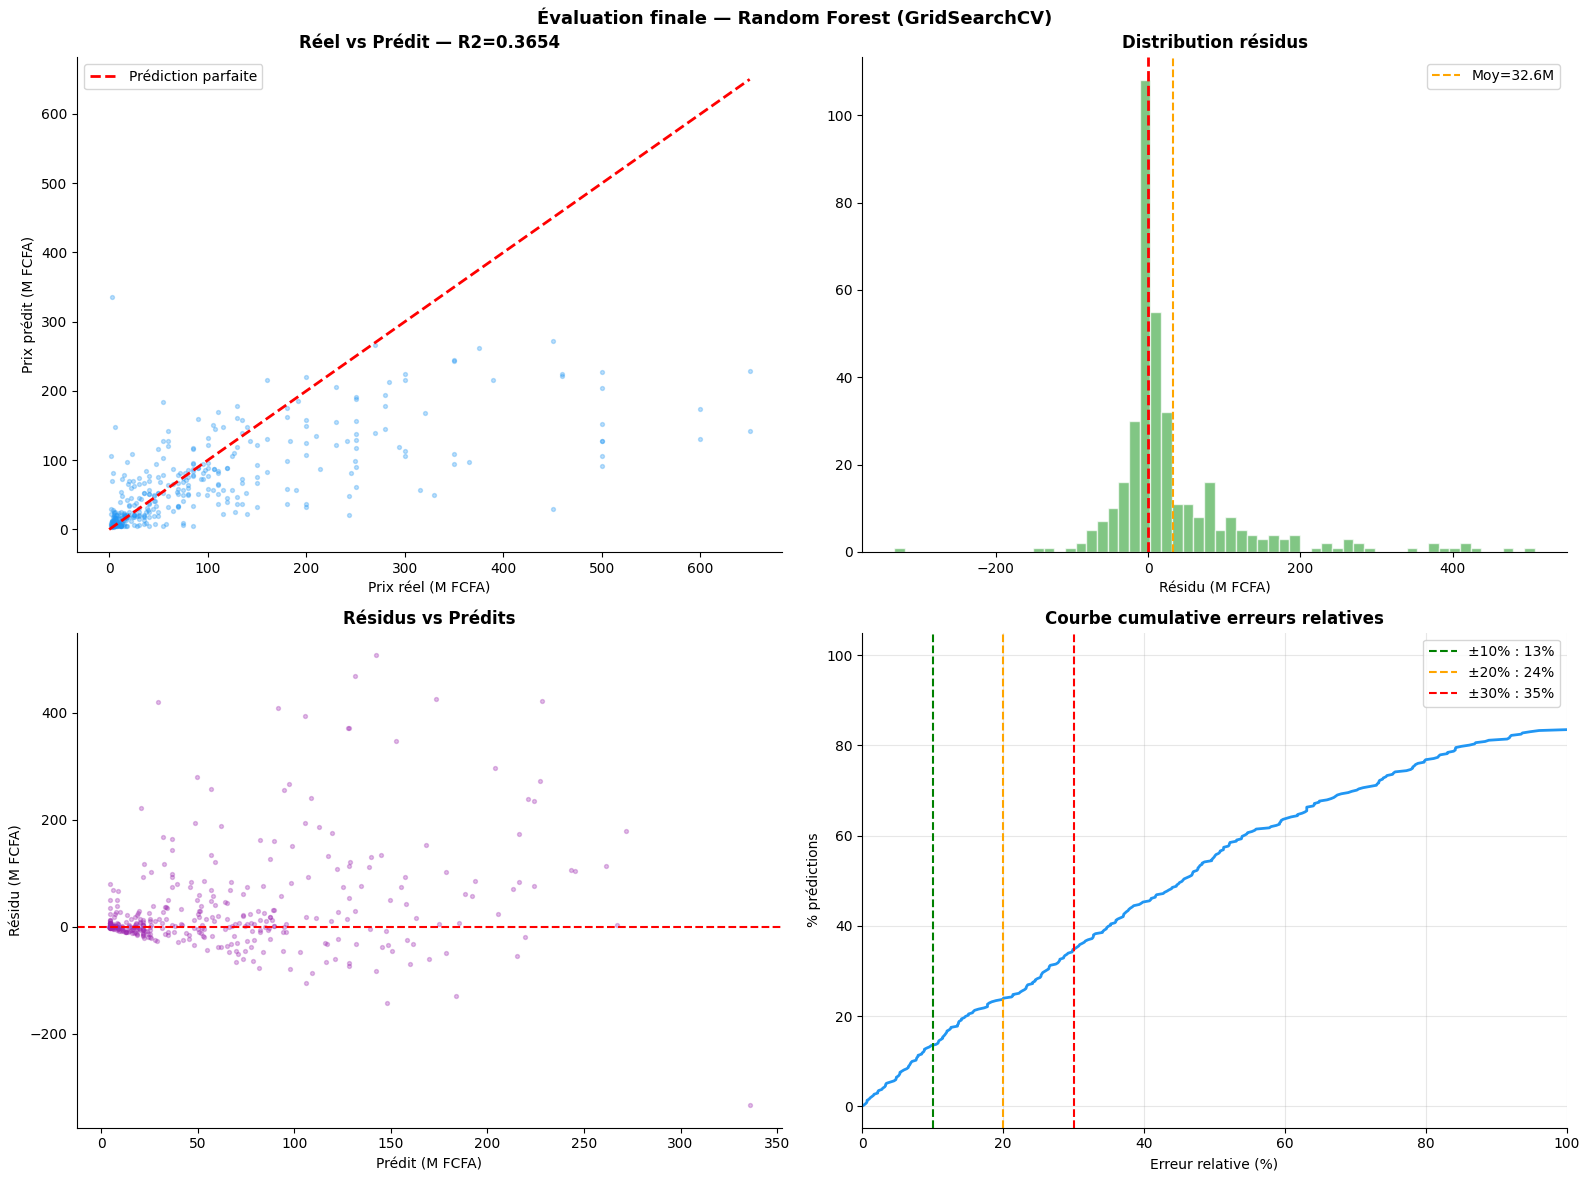

In [8]:
fig, axes = plt.subplots(2,2, figsize=(16,12))
lim = max(y_test.max(),yp_opt.max())/1e6

axes[0,0].scatter(y_test/1e6, yp_opt/1e6, alpha=0.3, s=8, color="#2196F3")
axes[0,0].plot([0,lim],[0,lim],"r--",lw=2,label="Prédiction parfaite")
axes[0,0].set_xlabel("Prix réel (M FCFA)"); axes[0,0].set_ylabel("Prix prédit (M FCFA)")
axes[0,0].set_title(f"Réel vs Prédit — R2={r2_f:.4f}", fontweight="bold"); axes[0,0].legend()

axes[0,1].hist(resid/1e6, bins=60, color="#4CAF50", alpha=0.7, edgecolor="white")
axes[0,1].axvline(0,color="red",linestyle="--",lw=2)
axes[0,1].axvline(resid.mean()/1e6,color="orange",linestyle="--",label=f"Moy={resid.mean()/1e6:.1f}M")
axes[0,1].set_xlabel("Résidu (M FCFA)"); axes[0,1].set_title("Distribution résidus",fontweight="bold")
axes[0,1].legend()

axes[1,0].scatter(yp_opt/1e6, resid/1e6, alpha=0.3, s=8, color="#9C27B0")
axes[1,0].axhline(0,color="red",linestyle="--",lw=1.5)
axes[1,0].set_xlabel("Prédit (M FCFA)"); axes[1,0].set_ylabel("Résidu (M FCFA)")
axes[1,0].set_title("Résidus vs Prédits", fontweight="bold")

rs_ = np.sort(rel_e); pct_ = np.arange(1,len(rs_)+1)/len(rs_)*100
axes[1,1].plot(rs_,pct_,"-",color="#2196F3",lw=2)
for v,l,c in [(10,f"{pct_10:.0f}%","green"),(20,f"{pct_20:.0f}%","orange"),(30,f"{pct_30:.0f}%","red")]:
    axes[1,1].axvline(v,color=c,linestyle="--",label=f"±{v}% : {l}")
axes[1,1].set_xlabel("Erreur relative (%)"); axes[1,1].set_ylabel("% prédictions")
axes[1,1].set_title("Courbe cumulative erreurs relatives", fontweight="bold")
axes[1,1].set_xlim(0,100); axes[1,1].legend(); axes[1,1].grid(True,alpha=0.3)

plt.suptitle(f"Évaluation finale — {key} ({best_method})", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig("../outputs/fig_evaluation_finale.png",dpi=150,bbox_inches="tight"); plt.show()


## 7. SHAP — Explication d'une prédiction individuelle

Cas illustratif — Bien le plus cher :
  Prix réel   : 2,500,000 FCFA
  Prix prédit : 335,844,802 FCFA


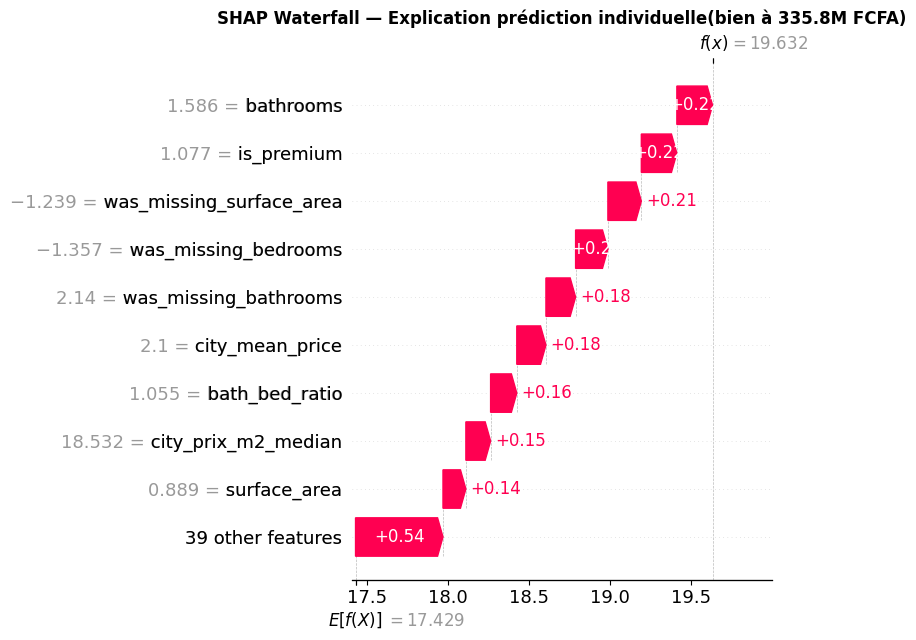

Ce graphique montre la contribution de chaque feature à la prédiction finale.
Utile pour expliquer les estimations aux clients et aux institutions.


In [10]:
# Waterfall plot SHAP — requis pour les rapports B2G (ICTD, 2023)
# Montre POURQUOI le modèle a prédit ce prix pour un bien spécifique
if SHAP:
    try:
        prep_X   = best_opt.named_steps["prep"].transform(X_test)
        model_m  = best_opt.named_steps["model"]
        explainer = shap.TreeExplainer(model_m)
        sv        = explainer(prep_X[:100])

        feat_names = (num_feats + [f"cat_{i}" for i in range(prep_X.shape[1]-len(num_feats))])[:prep_X.shape[1]]

        # Cas 1 : bien le plus cher (prédiction haute)
        idx_cher = np.argmax(yp_opt[:100])
        print(f"Cas illustratif — Bien le plus cher :")
        print(f"  Prix réel   : {y_test.values[idx_cher]:,.0f} FCFA")
        print(f"  Prix prédit : {yp_opt[idx_cher]:,.0f} FCFA")

        plt.figure(figsize=(14,8))
        shap.waterfall_plot(shap.Explanation(
            values=sv.values[idx_cher],
            base_values=sv.base_values[idx_cher],
            data=prep_X[idx_cher],
            feature_names=feat_names), show=False)
        plt.title(f"SHAP Waterfall — Explication prédiction individuelle(bien à {yp_opt[idx_cher]/1e6:.1f}M FCFA)",
                  fontweight="bold")
        plt.tight_layout()
        plt.savefig("../outputs/fig_shap_waterfall.png",dpi=150,bbox_inches="tight")
        plt.show()
        print("Ce graphique montre la contribution de chaque feature à la prédiction finale.")
        print("Utile pour expliquer les estimations aux clients et aux institutions.")
    except Exception as e:
        print(f"SHAP waterfall non disponible : {e}")
else:
    print("SHAP non installé. pip install shap")


## 8. Tests de prédiction sur des cas réels

In [13]:
from math import radians, sin, cos, sqrt, atan2

CITY_COORDS_PRED = {
    "Almadies":(14.7453,-17.5109), "Ngor":(14.7490,-17.5140),
    "Ouakam":(14.7237,-17.4942),   "Plateau":(14.6928,-17.4467),
    "Pikine":(14.7546,-17.3947),   "Fann":(14.6961,-17.4603),
    "Mermoz":(14.7100,-17.4750),   "Rufisque":(14.7156,-17.2736),
    "Yoff":(14.7575,-17.4900),     "Grand Yoff":(14.7500,-17.4600),
    "Thies":(14.7910,-16.9260),    "Mbour":(14.3641,-16.9658),
}
POI_REF = {"mer":[(14.7457,-17.5197),(14.7247,-17.5025)],
           "centre":(14.6928,-17.4467),"aeroport":(14.7397,-17.4902),
           "parc":(14.7122,-17.4488),"ucad":(14.6925,-17.4636),
           "vdn":(14.7200,-17.4600),"port":(14.6770,-17.4300),
           "corniche":(14.7100,-17.4800)}
PREMIUM_P = ["Almadies","Ngor","Ouakam","Mermoz","Fann","Plateau"]
PREMIUM2_P = ["Yoff","Sacre Coeur","Sicap","Hlm","Hann Maristes","Medina"]

def hav(la1,lo1,la2,lo2):
    R=6371; la1,lo1,la2,lo2=map(radians,[la1,lo1,la2,lo2])
    a=sin((la2-la1)/2)**2+cos(la1)*cos(la2)*sin((lo2-lo1)/2)**2
    return R*2*atan2(sqrt(a),sqrt(1-a))

def predict_bien(surface_area,bedrooms,bathrooms,city,property_type,source="coinafrique",
                 has_piscine=0,has_standing=0,has_vue_mer=0,has_titre_foncier=0,
                 has_parking=0,has_gardiennage=0):
    lat,lon = CITY_COORDS_PRED.get(city,(14.6928,-17.4467))
    dm  = min(hav(lat,lon,*p) for p in POI_REF["mer"])
    dc  = hav(lat,lon,*POI_REF["centre"])
    da  = hav(lat,lon,*POI_REF["aeroport"])
    dp  = hav(lat,lon,*POI_REF["parc"])
    du  = hav(lat,lon,*POI_REF["ucad"])
    dv  = hav(lat,lon,*POI_REF["vdn"])
    dpo = hav(lat,lon,*POI_REF["port"])
    dco = hav(lat,lon,*POI_REF["corniche"])
    zp  = 2 if city in PREMIUM_P else (1 if city in PREMIUM2_P else 0)
    isp = int(city in PREMIUM_P)
    rt  = (bedrooms or 0) + (bathrooms or 0)
    spr = surface_area/bedrooms if bedrooms and bedrooms>0 else surface_area

    row = {
        "surface_area":surface_area,"bedrooms":bedrooms,"bathrooms":bathrooms,"garage":0,
        "dist_mer":dm,"dist_centre":dc,"dist_aeroport":da,"dist_parc":dp,
        "dist_ucad":du,"dist_vdn":dv,"dist_port":dpo,"dist_corniche":dco,
        "zone_premium":zp,"is_premium":isp,"rooms_total":rt,"surface_per_room":spr,
        "bath_bed_ratio":bathrooms/bedrooms if bedrooms and bedrooms>0 else 0,
        "log_surface":np.log1p(surface_area),"log_dist_mer":np.log1p(dm),
        "log_dist_centre":np.log1p(dc),
        "has_standing":has_standing,"has_neuf":0,"has_renove":0,"has_piscine":has_piscine,
        "has_meuble":0,"has_climatise":0,"has_ascenseur":0,"has_cuisine_amer":0,
        "has_parking":has_parking,"has_jardin":0,"has_balcon":0,
        "has_gardiennage":has_gardiennage,"has_groupe_elec":0,"has_vue_mer":has_vue_mer,
        "has_vue_degagee":0,"has_concierge":0,"has_digicode":0,
        "has_titre_foncier":has_titre_foncier,"has_viabilise":0,"has_invest":0,
        "n_premium_feats":has_piscine+has_standing+has_gardiennage+has_vue_mer+has_titre_foncier,
        "was_missing_surface_area":0,"was_missing_bedrooms":0,"was_missing_bathrooms":0,
        "city_mean_price":float(df[df["city_mean_price"].notna()]["city_mean_price"].mean()) if "city_mean_price" in df.columns else 50e6,
        "city_median_price":float(df[df["city_median_price"].notna()]["city_median_price"].mean()) if "city_median_price" in df.columns else 40e6,
        "city_count":50,"city_prix_m2_median":300000,
        "property_type":property_type,"source":source,
    }
    Xp    = pd.DataFrame([row])
    cols  = [c for c in num_feats+cat_feats if c in Xp.columns]
    price = max(0, np.expm1(best_opt.predict(Xp[cols])[0]))
    margin= price * 0.15
    return {"Prix estimé":f"{price:,.0f} FCFA",
            "Fourchette": f"{max(0,price-margin):,.0f} — {price+margin:,.0f} FCFA",
            "En millions":f"{price/1e6:.2f} M FCFA",
            "Prix/m²":    f"{price/surface_area:,.0f} FCFA/m²" if surface_area else "N/A"}

cas = [
    dict(label="Villa 6p — Almadies (luxe, piscine, titre foncier, vue mer)",
         surface_area=350,bedrooms=5,bathrooms=4,city="Almadies",property_type="Villa",
         has_piscine=1,has_standing=1,has_vue_mer=1,has_titre_foncier=1,has_gardiennage=1),
    dict(label="Villa F4 — Ouakam (standing, parking)",
         surface_area=180,bedrooms=4,bathrooms=3,city="Ouakam",property_type="Villa",
         has_standing=1,has_parking=1,has_titre_foncier=1),
    dict(label="Appartement F3 — Mermoz (milieu de gamme)",
         surface_area=100,bedrooms=3,bathrooms=2,city="Mermoz",property_type="Appartement"),
    dict(label="Appartement F2 — Grand Yoff (populaire)",
         surface_area=60,bedrooms=2,bathrooms=1,city="Grand Yoff",property_type="Appartement"),
    dict(label="Terrain 400m² — Ngor (bord de mer)",
         surface_area=400,bedrooms=0,bathrooms=0,city="Ngor",property_type="Terrain",
         has_titre_foncier=1,has_vue_mer=1),
    dict(label="Villa F5 — Rufisque (périphérie)",
         surface_area=200,bedrooms=4,bathrooms=3,city="Rufisque",property_type="Villa"),
    dict(label="Villa resort — Mbour (Petite Côte)",
         surface_area=300,bedrooms=5,bathrooms=4,city="Mbour",property_type="Villa",
         has_piscine=1,has_vue_mer=1,has_standing=1),
]

print("="*70); print("  TESTS DE PRÉDICTION — 7 CAS RÉELS"); print("="*70)
for cas_ in cas:
    label = cas_.pop("label")
    res   = predict_bien(**cas_)
    print(f"{label}")
    for k,v in res.items(): print(f"   {k:<18} : {v}")


  TESTS DE PRÉDICTION — 7 CAS RÉELS
Villa 6p — Almadies (luxe, piscine, titre foncier, vue mer)
   Prix estimé        : 219,228,572 FCFA
   Fourchette         : 186,344,286 — 252,112,858 FCFA
   En millions        : 219.23 M FCFA
   Prix/m²            : 626,367 FCFA/m²
Villa F4 — Ouakam (standing, parking)
   Prix estimé        : 117,187,946 FCFA
   Fourchette         : 99,609,754 — 134,766,138 FCFA
   En millions        : 117.19 M FCFA
   Prix/m²            : 651,044 FCFA/m²
Appartement F3 — Mermoz (milieu de gamme)
   Prix estimé        : 56,720,893 FCFA
   Fourchette         : 48,212,759 — 65,229,027 FCFA
   En millions        : 56.72 M FCFA
   Prix/m²            : 567,209 FCFA/m²
Appartement F2 — Grand Yoff (populaire)
   Prix estimé        : 48,608,197 FCFA
   Fourchette         : 41,316,967 — 55,899,427 FCFA
   En millions        : 48.61 M FCFA
   Prix/m²            : 810,137 FCFA/m²
Terrain 400m² — Ngor (bord de mer)
   Prix estimé        : 58,371,473 FCFA
   Fourchette         

## 9. Sauvegarde et déploiement Django

In [14]:
MODEL_DIR    = os.path.join("..","properties","ml")
MODEL_PATH   = os.path.join(MODEL_DIR,"model.pkl")
RESULTS_PATH = os.path.join(MODEL_DIR,"results.json")
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump({
    "pipeline":             best_opt,
    "best_model_name":      key,
    "search_method":        best_method,
    "best_params":          {str(k):str(v) for k,v in best_params.items()},
    "features":             num_feats + cat_feats,
    "numeric_features":     num_feats,
    "categorical_features": cat_feats,
    "metrics": {
        "r2":r2_f,"mae":round(mae_f,2),"rmse":round(rmse_f,2),
        "mape":round(mape_f,2),"pct_20":round(pct_20,1),"pct_30":round(pct_30,1),
    },
}, MODEL_PATH)
print(f"Modèle sauvegardé    -> {MODEL_PATH}")

final = {
    "best_model":key,"search_method":best_method,
    "metrics":{"R2":round(r2_f,4),"MAE":round(mae_f,2),"RMSE":round(rmse_f,2),
               "MAPE (%)":round(mape_f,2),"pct_20":round(pct_20,1),"pct_30":round(pct_30,1)},
    "best_params":{str(k):str(v) for k,v in best_params.items()},
    "benchmark":{
        "Abidoye_Lagos_2018_MAPE": 15.94,
        "Ouchlif_Maroc_2025_R2":   0.926,
        "Notre_MAPE": round(mape_f,2),
        "Notre_R2":   round(r2_f,4),
    }
}
with open(RESULTS_PATH,"w") as f:
    json.dump(final, f, indent=2, default=str)
print(f"Résultats sauvegardés -> {RESULTS_PATH}")

print("""
RÉCAPITULATIF COMPLET DU PIPELINE
====================================
NB1 : EDA - 5 sources, CV, séparation vente/location sur données réelles
NB2 : 40+ features (20 NLP + 8 POI + Target Encoding + was_missing)
NB3 : 10 modèles + Stacking XGB+LGB+RF+Ridge + SHAP
NB4 : GridSearch + RandomizedSearch 150 iter + Learning curves + 7 cas réels

DÉPLOIEMENT API DJANGO :
  POST /api/properties/predict/    -> prédiction de prix
  GET  /api/properties/ml/results/ -> métriques + benchmark vs littérature
""")


Modèle sauvegardé    -> ..\properties\ml\model.pkl
Résultats sauvegardés -> ..\properties\ml\results.json

RÉCAPITULATIF COMPLET DU PIPELINE
NB1 : EDA - 5 sources, CV, séparation vente/location sur données réelles
NB2 : 40+ features (20 NLP + 8 POI + Target Encoding + was_missing)
NB3 : 10 modèles + Stacking XGB+LGB+RF+Ridge + SHAP
NB4 : GridSearch + RandomizedSearch 150 iter + Learning curves + 7 cas réels

DÉPLOIEMENT API DJANGO :
  POST /api/properties/predict/    -> prédiction de prix
  GET  /api/properties/ml/results/ -> métriques + benchmark vs littérature



In [15]:
import joblib, json, os

os.makedirs("../properties/ml", exist_ok=True)

# Sauvegarder le meilleur modèle
joblib.dump(best_model,      "../properties/ml/model.pkl")
joblib.dump(preprocessor,    "../properties/ml/preprocessor.pkl")

# Sauvegarder les métriques
results = {
    "model_name": "XGBoost",
    "r2":   float(r2_score(y_test, y_pred)),
    "mae":  float(mean_absolute_error(y_test, y_pred)),
    "rmse": float(np.sqrt(mean_squared_error(y_test, y_pred))),
}
with open("../properties/ml/results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Modèle exporté dans properties/ml/")

NameError: name 'best_model' is not defined